# Exploratory Data Analysis

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.colors as mcolors
import os
import random
from PIL import Image
import cv2


# Raw data

In [ ]:
# get the number of files in the Eyes_detection and Face_detection directories
eyes_folder = "Eyes_detection/"
face_folder = "Face_detection/"

_, _, eyes_files = next(os.walk(eyes_folder))
_, _, face_files = next(os.walk(face_folder))

print("Eyes files: ", len(eyes_files))
print("Face files: ", len(face_files))

Eyes files:  1087
Face files:  2222


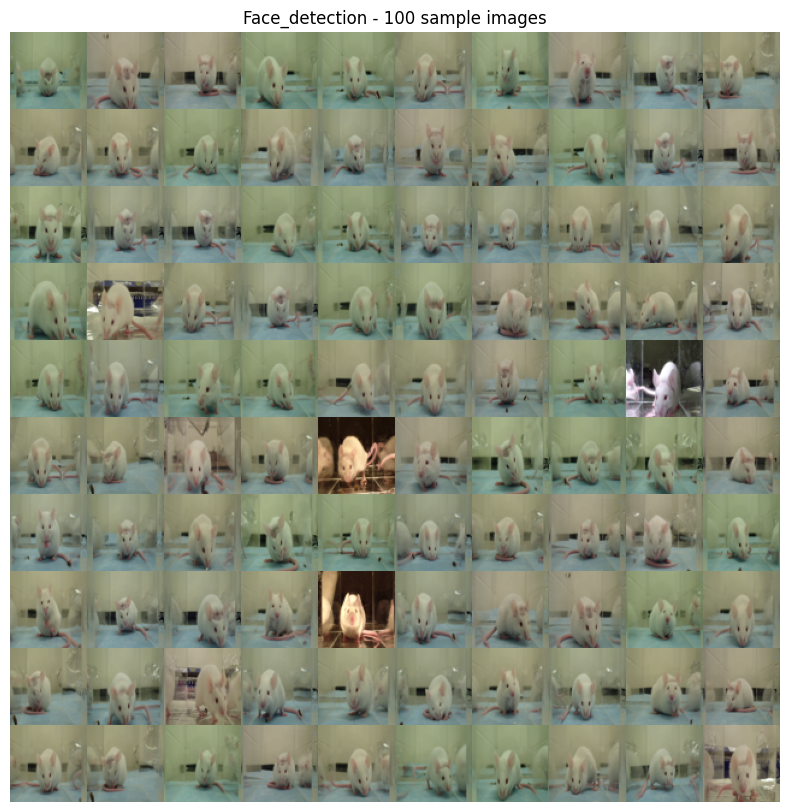

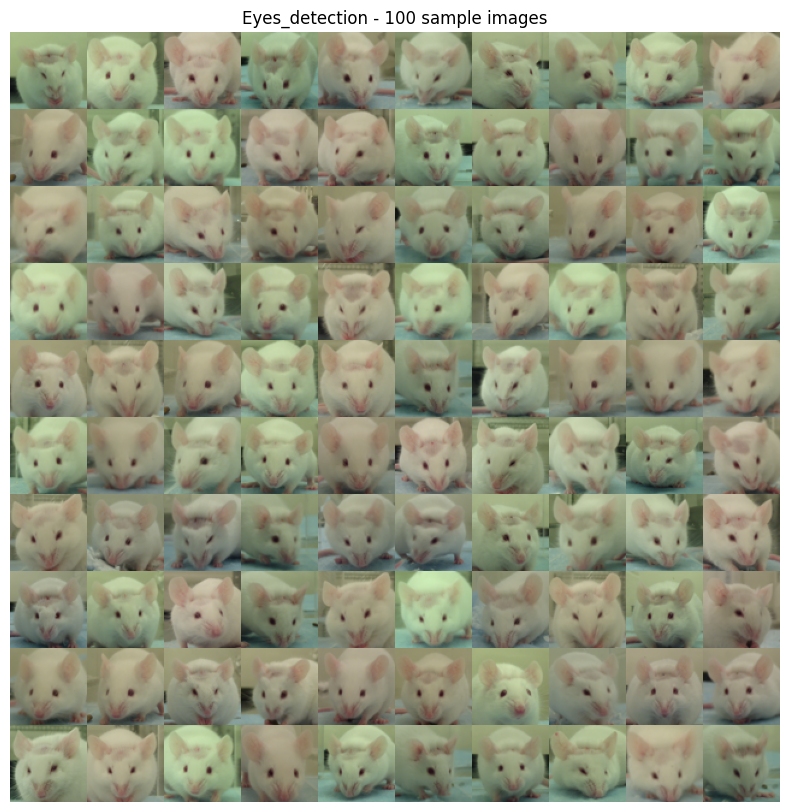

In [ ]:
# create a sample of random images for each dataset (each presented in a grid of 10x10)
def create_image_grid(image_paths, folder, grid_size=10, thumb_size=(64, 64)):
    grid_img = Image.new('RGB', (thumb_size[0]*grid_size, thumb_size[1]*grid_size))
    
    for i, filename in enumerate(image_paths[:grid_size*grid_size]):
        try:
            path = os.path.join(folder, filename)
            img = Image.open(path).convert("RGB")
            img = img.resize(thumb_size)
            x = (i % grid_size) * thumb_size[0]
            y = (i // grid_size) * thumb_size[1]
            grid_img.paste(img, (x, y))
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    return grid_img

sample_faces = random.sample(face_files, min(100, len(face_files)))
sample_eyes = random.sample(eyes_files, min(100, len(eyes_files)))

face_grid = create_image_grid(sample_faces, face_folder)
plt.figure(figsize=(10, 10))
plt.title("Face_detection - 100 sample images")
plt.imshow(face_grid)
plt.axis('off')
plt.show()

eyes_grid = create_image_grid(sample_eyes, eyes_folder)
plt.figure(figsize=(10, 10))
plt.title("Eyes_detection - 100 sample images")
plt.imshow(eyes_grid)
plt.axis('off')
plt.show()

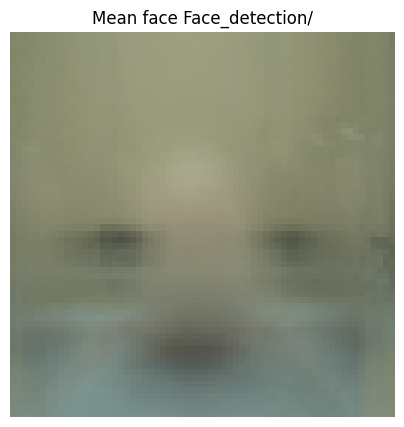

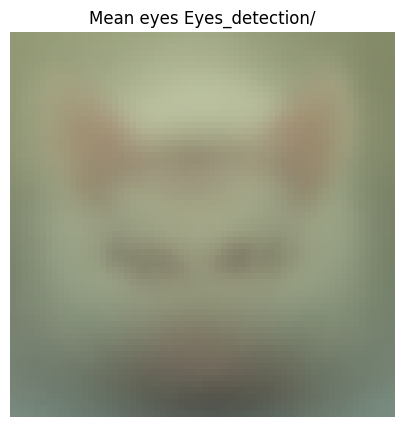

In [ ]:
def compute_mean_image(folder, file_list, size=(64,64)):
    total = np.zeros((size[1], size[0], 3), np.float64)

    for file in file_list:
        path = os.path.join(folder, file)
        img = cv2.imread(path)  # BGR format
        if img is None:
            continue
        img = cv2.resize(img, size)
        total += img[..., ::-1]  # BGR --> RGB
    mean = (total / len(file_list)).astype(np.uint8)
    return Image.fromarray(mean)

mean_face_img = compute_mean_image(face_folder, face_files)
plt.figure(figsize=(5, 5))
plt.title(f"Mean face {face_folder}")
plt.imshow(mean_face_img)
plt.axis('off')
plt.show()

mean_eyes_img = compute_mean_image(eyes_folder, eyes_files)
plt.figure(figsize=(5, 5))
plt.title(f"Mean eyes {eyes_folder}")
plt.imshow(mean_eyes_img)
plt.axis('off')
plt.show()

# Labels

In [20]:
def count_animal_numbers(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    records = []
    for img_name, entries in data.items():
        for entry in entries:
            records.append({
                "Image": img_name,
                "AnimalNumber": entry.get("AnimalNumber")
            })

    df = pd.DataFrame(records)
    counts = df["AnimalNumber"].value_counts().sort_index()

    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    colormap = mpl.colormaps["Reds"]
    colors = [colormap(norm(value)) for value in counts.values]

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar", color=colors)
    plt.xlabel("AnimalNumber")
    plt.ylabel("count")
    plt.title(f"AnimalNumber distribution in {path}")
    plt.tight_layout()
    plt.show()

    return counts

In [21]:
# grimmace score distribution
def count_grimmace_scores(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    records = []
    for img_name, entries in data.items():
        for entry in entries:
            records.append({
                "Image": img_name,
                "GrimmaceScore": entry.get("GrimaceScale")
            })
    
    df = pd.DataFrame(records)
    counts = df["GrimmaceScore"].value_counts().sort_index()
    
    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    colormap = mpl.colormaps["Reds"]
    colors = [colormap(norm(value)) for value in counts.values]

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar", color=colors)
    plt.xlabel("GrimmaceScore")
    plt.ylabel("count")
    plt.title(f"GrimmaceScore distribution")
    plt.tight_layout()
    plt.show()

    return counts
            

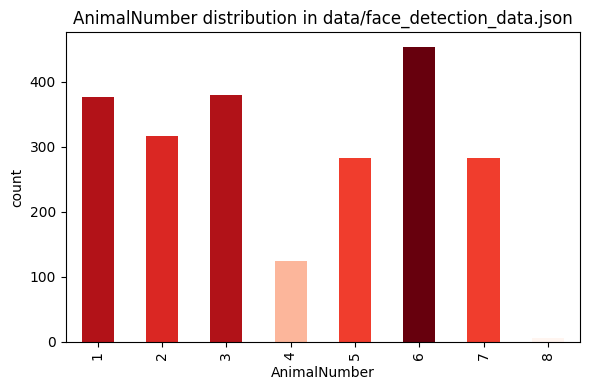

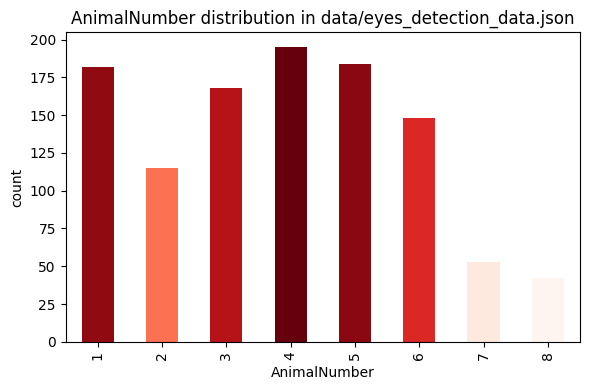

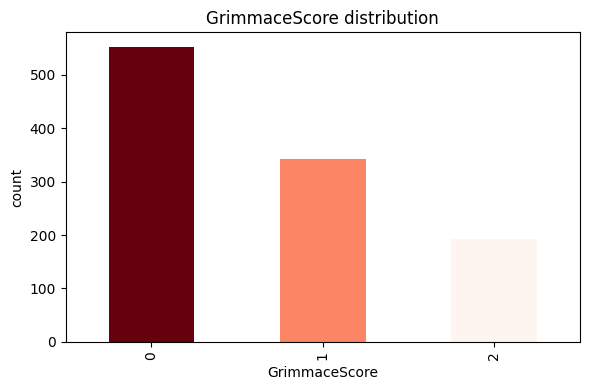

GrimmaceScore
0    552
1    342
2    193
Name: count, dtype: int64

In [22]:
count_animal_numbers("data/face_detection_data.json")
count_animal_numbers("data/eyes_detection_data.json")
count_grimmace_scores("data/eyes_detection_data.json")